### There are several ways to establish connection to local postgresql db but we will use pandas and sqlalchemy libraries

### To install it RUN THE NEXT CELL BY CLICKING ON IT AND SHIFT+ENTER or click RUN BUTTON ABOVE

In [6]:
%conda install -y sqlalchemy psycopg2

3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: c:\Users\Bohdan\anaconda3\envs\python-lab

  added / updated specs:
    - psycopg2
    - sqlalchemy


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    ca-certificates-2026.8.13  |       haa95532_0         107 KB
    greenlet-3.2.4             |   py39h885b0b7_0         204 KB
    libkrb5-1.22.2             |       h3d06f0e_0         677 KB
    libpq-17.9                 |       hb13705e_1         3.8 MB
    psycopg2-2.9.10            |   py39h827c3e9_0         236 KB
    sqlalchemy-2.0.43          |   py39hda9a48d_0         5.9 MB
    ------------------------------------------------------------
                                           Total:        10.9 MB

The following NEW packages will be INSTALLED:

  greenlet     



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c defaults conda




### As now we have proper libraries we can import and use them 

### Execute the following cell 

In [1]:
import pandas as pd
from sqlalchemy import create_engine

def connect_to_db(dbname: str, user: str, password: str, host: str = "localhost", port: str = "5432"):
    try:
        conn_str = f"postgresql://{user}:{password}@{host}:{port}/{dbname}"
        engine = create_engine(conn_str)
        print(f"Engine created for database: {dbname}")
        return engine
    except Exception as e:
        print(f"Error creating engine for {dbname}: {e}")
        return None


### in previous cell we creted connect_to_db function which we can reuse to connect to both of our DBs, we just need to provide propper attributers. 

### In the next cell you can find example of establishing connection to SRC DB and reading data from s1.s1_channels into separate pandas dataframe

### Execute the following cell 

In [2]:
src_engine = connect_to_db(
    dbname="dwh_src_hw_db",
    user="postgres",
    password="admin"
)

s1_channels_df = pd.read_sql("SELECT * FROM s1.s1_channels", src_engine)
s1_channels_df

Engine created for database: dwh_src_hw_db


,channel_id,channel_name,channel_location
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
153,154,YAOBAO.COM,Internet
154,155,CATALOG.ONLINER.BY,Internet
155,156,5ELEMENT.BY,Internet
156,157,ALLEGRO.PL,Internet


 ## YOUR TASK IS TO ESTABLISH SEPARATE 

 trg_engine 

 ## and conect to dwh_hw_db in the next cell

In [5]:
trg_engine = connect_to_db(
    dbname="dwh_hw_db",
    user="postgres",
    password="admin"
)

lnd_s1_channels_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s1_channels",
    trg_engine
)

lnd_s1_channels_df


Engine created for database: dwh_hw_db


,channel_id,channel_name,channellocation
0,1,STORE - 1,621 Hovde Circle
1,2,STORE - 2,9459 Trailsway Terrace
2,3,STORE - 3,23 Transport Street
3,4,STORE - 4,7 Pond Place
4,5,STORE - 5,6799 Armistice Avenue
...,...,...,...
151,152,EBAY.COM,N/A - Internet
152,153,ALIEXPRESS.COM,N/A - Internet
153,154,YAOBAO.COM,N/A - Internet
154,155,CATALOG-ONLINER.BY,N/A - Internet


#### AS we have 2 DFs with data from 2 tables we need to compare them. To do so we can create separate DF s1_channels_comparison_df

### Execute the following cell 

In [6]:
s1_channels_comparison_df = s1_channels_df.merge(
    lnd_s1_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True  
)
s1_channels_comparison_df

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge
0,1,STORE - 1,621 Hovde Circle,STORE - 1,621 Hovde Circle,both
1,10,STORE - 10,6840 Pennsylvania Terrace,STORE - 10,6840 Pennsylvania Terrace,both
2,100,STORE - 100,72760 Helena Avenue,STORE - 100,72760 Helena Avenue,both
3,101,STORE - 101,40 Lyons Place,STORE - 101,40 Lyons Place,both
4,102,STORE - 102,04 Ludington Pass,STORE - 102,04 Ludington Pass,both
...,...,...,...,...,...,...
153,95,STORE - 95,6354 Lukken Circle,STORE - 95,6354 Lukken Circle,both
154,96,STORE - 96,1 Lighthouse Bay Way,STORE - 96,1 Lighthouse Bay Way,both
155,97,STORE - 97,03 Moland Parkway,STORE - 97,03 Moland Parkway,both
156,98,STORE - 98,24450 Kim Center,STORE - 98,24450 Kim Center,both


### Since we use indicator=True in the merge, pandas automatically provides the _merge column with values left_only, right_only, or both for the ID values.

### However, we want to make the statuses more meaningful, similar to what we did in SQL and also check for differences in other attributes, not just IDs.
### For this reason, I have prepared a separate function specifically for computing reconciliation_status for the channels table.

### Execute the following cell 

In [7]:
def get_s1_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'
    elif row['_merge'] == 'right_only':
        return 'Only in landing'
    
    mismatches = []
    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')
    if row['channel_location'] != row['channellocation']:
        mismatches.append('channel_location')
    
    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)
    
    return 'Match'

### Since this function expects a single row as input, we can apply it to our s1_channel_comparison_df and create a new column to store the adapted reconciliation statuses.

### Execute the following cell 


In [8]:
s1_channels_comparison_df['reconciliation_status'] = s1_channels_comparison_df.apply(get_s1_channels_reconciliation_status, axis=1)

### And now, let’s keep only the rows with discrepancies (i.e., excluding rows where everything matches).

In [10]:
s1_channels_issues_df = s1_channels_comparison_df[s1_channels_comparison_df['reconciliation_status'] != 'Match']
display(s1_channels_issues_df.head(20))

,channel_id,channel_name_src,channel_location,channel_name_lnd,channellocation,_merge,reconciliation_status
58,151,AMAZON.COM,Internet,AMAZON.COM,N/A - Internet,both,Mismatch in channel_location
59,152,EBAY.COM,Internet,EBAY.COM,N/A - Internet,both,Mismatch in channel_location
60,153,ALIEXPRESS.COM,Internet,ALIEXPRESS.COM,N/A - Internet,both,Mismatch in channel_location
61,154,YAOBAO.COM,Internet,YAOBAO.COM,N/A - Internet,both,Mismatch in channel_location
62,155,CATALOG.ONLINER.BY,Internet,CATALOG-ONLINER.BY,N/A - Internet,both,"Mismatch in channel_name, channel_location"
63,156,5ELEMENT.BY,Internet,5ELEMENT.BY,N/A - Internet,both,Mismatch in channel_location
64,157,ALLEGRO.PL,Internet,NaN,NaN,left_only,Only in source
65,158,AMAZON.COM,Internet,NaN,NaN,left_only,Only in source


# Task: Reconcile all other table pairs from SRC and LND, similar to what we did for the channels table.

## Instructions:

### Tables to compare:

###### s1.s1_products → lnd.lnd_s1_products
###### s1.s1_sales → lnd.lnd_s1_sales
###### s2.s2_channels → lnd.lnd_s2_channels
###### s2.s2_client_sales → lnd.lnd_s2_client_sales
###### s2.s2_clients → lnd.lnd_s2_clients
###### s2.s2_locations → lnd.lnd_s2_locations

## For each table pair:

### 1. Load the SRC and LND tables into pandas DataFrames.
### 2. Perform a full outer merge on the primary key column(s).
### 3. Apply a function like get_reconciliation_status(row) to classify each row into statuses:
###### 'Only in source'
###### 'Only in landing'
###### 'Mismatch in <column_name>'
###### 'Match'

### Keep only rows with issues (statuses != 'Match').

## 4. Create a consolidated result DataFrame with the following columns:

###### table_name	Name of the table being compared
###### key_column	Primary key column used for reconciliation
###### src_id	ID value from source table
###### trg_id	ID value from landing table
###### reconciliation_status	Status of the row (Only in source, Only in landing, etc.)

## 5. Populate the final result DataFrame with all discrepancies from all table comparisons.

### Tips / Methods:

### Use pd.merge(..., how='outer', indicator=True) to combine SRC and LND tables.
### Apply your reconciliation status function row-wise with df.apply(..., axis=1).
### Filter only rows with issues using df[df['reconciliation_status'] != 'Match'].
### Concatenate multiple issues_df DataFrames using pd.concat([...], ignore_index=True) to create the final consolidated DataFrame.

In [ ]:
s1_products_df = pd.read_sql(
    "SELECT * FROM s1.s1_products",
    src_engine
)

lnd_s1_products_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s1_products",
    trg_engine
)

s1_products_df.head()

,product_id,cost,product_name
0,1,6.33,mirror
1,2,3.01,drill press
2,3,7.55,screw
3,4,6.69,soap
4,5,3.59,doll


In [13]:
s1_products_comparison_df = s1_products_df.merge(
    lnd_s1_products_df,
    on='product_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

s1_products_comparison_df

,product_id,cost_src,product_name_src,cost_lnd,product_name_lnd,_merge
0,1,6.33,mirror,6.33,mirror,both
1,10,2.4,bananas,2.4,bananas,both
2,11,3.19,thermostat,3.19,thermostat,both
3,12,1.71,zipper,1.71,zipper,both
4,13,5.64,desk,5.64,desk,both
5,14,6.91,floor,6.91,floor,both
6,15,9.4,playing card,9.4,playing card,both
7,16,3.16,boom box,3.16,boom box,both
8,17,6.47,leg warmers,6.47,leg warmers,both
9,18,2.64,coasters,2.64,coasters,both


In [14]:
def get_s1_products_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'

    if row['_merge'] == 'right_only':
        return 'Only in target'

    mismatches = []

    if row['cost_src'] != row['cost_lnd']:
        mismatches.append('cost')

    if row['product_name_src'] != row['product_name_lnd']:
        mismatches.append('product_name')

    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)

    return 'Match'


s1_products_comparison_df['reconciliation_status'] = (
    s1_products_comparison_df.apply(
        get_s1_products_reconciliation_status,
        axis=1
    )
)

In [15]:
s1_products_issues_df = s1_products_comparison_df[
    s1_products_comparison_df['reconciliation_status'] != 'Match'
]

display(s1_products_issues_df)

,product_id,cost_src,product_name_src,cost_lnd,product_name_lnd,_merge,reconciliation_status
45,50,NaN,NaN,9.06,helmet,right_only,Only in target


In [16]:
s1_sales_df = pd.read_sql(
    "SELECT * FROM s1.s1_sales",
    src_engine
)

lnd_s1_sales_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s1_sales",
    trg_engine
)

print("Source rows:", len(s1_sales_df))
print("Landing rows:", len(lnd_s1_sales_df))

Source rows: 22400
Landing rows: 22224


In [17]:
s1_sales_comparison_df = s1_sales_df.merge(
    lnd_s1_sales_df,
    how='outer',
    on=[
        'client_id',
        'channel_id',
        'sale_date',
        'units',
        'product_id',
        'purchase_date'
    ],
    indicator=True
)

s1_sales_issues_df = s1_sales_comparison_df[
    s1_sales_comparison_df['_merge'] != 'both'
].copy()

s1_sales_issues_df['reconciliation_status'] = (
    s1_sales_issues_df['_merge'].map({
        'left_only': 'Only in source',
        'right_only': 'Only in target'
    })
)

display(s1_sales_issues_df)

,client_id,channel_id,sale_date,units,product_id,purchase_date,_merge,reconciliation_status
180,104,123,03-MAY-06,14,35,09-MAY-06,left_only,Only in source
339,108,36,20-OCT-05,1,23,21-OCT-05,left_only,Only in source
417,110,110,17-APR-05,4,8,25-APR-05,left_only,Only in source
508,112,84,19-JAN-06,11,10,21-JAN-06,left_only,Only in source
509,112,86,18-NOV-06,11,32,23-NOV-06,left_only,Only in source
...,...,...,...,...,...,...,...,...
21368,71,117,18-MAY-05,5,47,22-MAY-05,left_only,Only in source
21673,8,119,15-MAR-05,5,28,19-MAR-05,left_only,Only in source
21940,87,26,17-JAN-06,9,9,18-JAN-06,left_only,Only in source
22107,91,23,31-AUG-05,10,25,06-SEP-05,left_only,Only in source


In [18]:
s1_sales_issues_df['reconciliation_status'].value_counts()

reconciliation_status
Only in source    176
Name: count, dtype: int64

In [19]:
s2_channels_df = pd.read_sql(
    "SELECT * FROM s2.s2_channels",
    src_engine
)

lnd_s2_channels_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s2_channels",
    trg_engine
)

print("Source rows:", len(s2_channels_df))
print("Landing rows:", len(lnd_s2_channels_df))

display(s2_channels_df.head())
display(lnd_s2_channels_df.head())

Source rows: 37
Landing rows: 37


,channel_id,channel_name,location_id
0,ch1,Cold sales (phone),1
1,ch2,alibaba.com,2
2,ch3,kufar.by,2
3,ch4,yandex.market.by,2
4,ch5,avito.ru,2


,channel_id,channel_name,location_id
0,ch1,Cold sales (phone),1
1,ch2,alibaba.com,2
2,ch3,kufar.by,2
3,ch4,yandex.market.by,2
4,ch5,avito.ru,2


In [20]:
s2_channels_comparison_df = s2_channels_df.merge(
    lnd_s2_channels_df,
    on='channel_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

In [21]:
def get_s2_channels_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'

    if row['_merge'] == 'right_only':
        return 'Only in target'

    mismatches = []

    if row['channel_name_src'] != row['channel_name_lnd']:
        mismatches.append('channel_name')

    if row['location_id_src'] != row['location_id_lnd']:
        mismatches.append('location_id')

    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)

    return 'Match'


s2_channels_comparison_df['reconciliation_status'] = (
    s2_channels_comparison_df.apply(
        get_s2_channels_reconciliation_status,
        axis=1
    )
)

In [22]:
s2_channels_issues_df = s2_channels_comparison_df[
    s2_channels_comparison_df['reconciliation_status'] != 'Match'
]

display(s2_channels_issues_df)

print("Total issues:", len(s2_channels_issues_df))

,channel_id,channel_name_src,location_id_src,channel_name_lnd,location_id_lnd,_merge,reconciliation_status


Total issues: 0


In [23]:
s2_client_sales_df = pd.read_sql(
    "SELECT * FROM s2.s2_client_sales",
    src_engine
)

lnd_s2_client_sales_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s2_client_sales",
    trg_engine
)

print("Source rows:", len(s2_client_sales_df))
print("Landing rows:", len(lnd_s2_client_sales_df))

display(s2_client_sales_df.head())
display(lnd_s2_client_sales_df.head())

Source rows: 1296
Landing rows: 1291


,client_id,channel_id,saled_at,product_id,product_name,product_price,product_amount,sold_date
0,cl7,ch17,12-JUL-11,pr102,Catwalk Boots,156.1208571,2,13-JUL-11
1,cl61,ch7,03-MAY-11,pr103,Magnum Footwear Lifestyle,157.9545714,7,04-MAY-11
2,cl11,ch25,13-OCT-11,pr105,Rialto Boots,161.622,7,14-OCT-11
3,cl68,ch34,07-JUL-12,pr107,"Alfajr WY16B Youth Digital Watch - For Men, Boys",165.2894286,7,08-JUL-12
4,cl65,ch8,01-NOV-11,pr108,La Briza Ashley Boots,167.1231429,3,02-NOV-11


,client_id,channel_id,saled_at,product_id,product_name,product_price,product_amount,sold_date
0,cl7,ch17,12-JUL-11,pr102,Catwalk Boots,156.1208571,2,13-JUL-11
1,cl61,ch7,03-MAY-11,pr103,Magnum Footwear Lifestyle,157.9545714,7,04-MAY-11
2,cl11,ch25,13-OCT-11,pr105,Rialto Boots,161.622,7,14-OCT-11
3,cl68,ch34,07-JUL-12,pr107,"Alfajr WY16B Youth Digital Watch - For Men, Boys",165.2894286,7,08-JUL-12
4,cl65,ch8,01-NOV-11,pr108,La Briza Ashley Boots,167.1231429,3,02-NOV-11


In [24]:
s2_client_sales_comparison_df = s2_client_sales_df.merge(
    lnd_s2_client_sales_df,
    on=[
        'client_id',
        'channel_id',
        'saled_at',
        'product_id'
    ],
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

In [25]:
def get_s2_client_sales_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'

    if row['_merge'] == 'right_only':
        return 'Only in target'

    mismatches = []

    if row['product_name_src'] != row['product_name_lnd']:
        mismatches.append('product_name')

    if row['product_price_src'] != row['product_price_lnd']:
        mismatches.append('product_price')

    if row['product_amount_src'] != row['product_amount_lnd']:
        mismatches.append('product_amount')

    if row['sold_date_src'] != row['sold_date_lnd']:
        mismatches.append('sold_date')

    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)

    return 'Match'


s2_client_sales_comparison_df['reconciliation_status'] = (
    s2_client_sales_comparison_df.apply(
        get_s2_client_sales_reconciliation_status,
        axis=1
    )
)

In [26]:
s2_client_sales_issues_df = s2_client_sales_comparison_df[
    s2_client_sales_comparison_df['reconciliation_status'] != 'Match'
]

display(s2_client_sales_issues_df)

print("Total issues:", len(s2_client_sales_issues_df))

,client_id,channel_id,saled_at,product_id,product_name_src,product_price_src,product_amount_src,sold_date_src,product_name_lnd,product_price_lnd,product_amount_lnd,sold_date_lnd,_merge,reconciliation_status
12,cl10,ch18,04-SEP-11,pr118,Lyc White Casual Boots,185.4602857,1,05-SEP-11,NaN,NaN,NaN,NaN,left_only,Only in source
306,cl27,ch26,28-MAR-10,pr85,Redbag Eight Armed Goddess Sherawali Maa Showp...,124.9477143,3,29-MAR-10,NaN,NaN,NaN,NaN,left_only,Only in source
575,cl42,ch8,28-SEP-10,pr105,Rialto Boots,161.622,6,29-SEP-10,NaN,NaN,NaN,NaN,left_only,Only in source
671,cl49,ch11,15-JUN-10,pr95,"Camerii WM64 Elegance Analog Watch - For Men,...",143.2848571,4,16-JUN-10,NaN,NaN,NaN,NaN,left_only,Only in source
995,cl65,ch4,13-NOV-12,pr111,Shuz Touch Boots,172.6242857,2,14-NOV-12,NaN,NaN,NaN,NaN,left_only,Only in source


Total issues: 5


In [27]:
s2_client_sales_issues_df['reconciliation_status'].value_counts()

reconciliation_status
Only in source    5
Name: count, dtype: int64

In [28]:
s2_clients_df = pd.read_sql(
    "SELECT * FROM s2.s2_clients",
    src_engine
)

lnd_s2_clients_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s2_clients",
    trg_engine
)

print("Source rows:", len(s2_clients_df))
print("Landing rows:", len(lnd_s2_clients_df))

display(s2_clients_df.head())
display(lnd_s2_clients_df.head())

Source rows: 80
Landing rows: 80


,client_id,first_name,last_name,email,phone_code,phone_number,first_purchase,valid_from,valid_to
0,cl1,Dionisio,Newlove,dnewlove0@privacy.gov.au,375,2175622666,17-Mar-01,17-Mar-01,12-Mar-21
1,cl2,Hewitt,Thunderman,hthunderman1@wikimedia.org,7,6589250013,16-Jan-01,16-Jan-01,11-Jan-21
2,cl3,Derril,Croucher,dcroucher2@photobucket.com,1,2599614535,31-Mar-01,31-Mar-01,26-Mar-21
3,cl4,Thaine,Lassen,tlassen3@scientificamerican.com,375,3248135744,2-Mar-02,2-Mar-02,25-Feb-22
4,cl5,Bronny,Gerriets,bgerriets4@theglobeandmail.com,1,8224596380,9-Dec-00,9-Dec-00,4-Dec-20


,client_id,first_name,last_name,email,phone_code,phone_number,first_purchase,valid_from,valid_to
0,cl1,Dionisio,Newlove,dnewlove0@privacy.gov.au,375,2175622666,17-Mar-01,17-Mar-01,12-Mar-21
1,cl2,Hewitt,Thunderman,hthunderman1@wikimedia.org,7,6589250013,16-Jan-01,16-Jan-01,11-Jan-21
2,cl3,Derril,Croucher,dcroucher2@photobucket.com,1,2599614535,31-Mar-01,31-Mar-01,26-Mar-21
3,cl4,Thaine,Lassen,tlassen3@scientificamerican.com,375,3248135744,2-Mar-02,2-Mar-02,25-Feb-22
4,cl5,Bronny,Gerriets,bgerriets4@theglobeandmail.com,1,8224596380,9-Dec-00,9-Dec-00,4-Dec-20


In [29]:
s2_clients_comparison_df = s2_clients_df.merge(
    lnd_s2_clients_df,
    on='client_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

In [30]:
def get_s2_clients_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'

    if row['_merge'] == 'right_only':
        return 'Only in target'

    mismatches = []

    if row['first_name_src'] != row['first_name_lnd']:
        mismatches.append('first_name')

    if row['last_name_src'] != row['last_name_lnd']:
        mismatches.append('last_name')

    if row['email_src'] != row['email_lnd']:
        mismatches.append('email')

    if row['phone_code_src'] != row['phone_code_lnd']:
        mismatches.append('phone_code')

    if row['phone_number_src'] != row['phone_number_lnd']:
        mismatches.append('phone_number')

    if row['first_purchase_src'] != row['first_purchase_lnd']:
        mismatches.append('first_purchase')

    if row['valid_from_src'] != row['valid_from_lnd']:
        mismatches.append('valid_from')

    if row['valid_to_src'] != row['valid_to_lnd']:
        mismatches.append('valid_to')

    if mismatches:
        return 'Mismatch in ' + ', '.join(mismatches)

    return 'Match'


s2_clients_comparison_df['reconciliation_status'] = (
    s2_clients_comparison_df.apply(
        get_s2_clients_reconciliation_status,
        axis=1
    )
)

In [31]:
s2_clients_issues_df = s2_clients_comparison_df[
    s2_clients_comparison_df['reconciliation_status'] != 'Match'
]

display(s2_clients_issues_df)

print("Total issues:", len(s2_clients_issues_df))

,client_id,first_name_src,last_name_src,email_src,phone_code_src,phone_number_src,first_purchase_src,valid_from_src,valid_to_src,first_name_lnd,last_name_lnd,email_lnd,phone_code_lnd,phone_number_lnd,first_purchase_lnd,valid_from_lnd,valid_to_lnd,_merge,reconciliation_status


Total issues: 0


In [32]:
s2_locations_df = pd.read_sql(
    "SELECT * FROM s2.s2_locations",
    src_engine
)

lnd_s2_locations_df = pd.read_sql(
    "SELECT * FROM lnd.lnd_s2_locations",
    trg_engine
)

print("Source rows:", len(s2_locations_df))
print("Landing rows:", len(lnd_s2_locations_df))

display(s2_locations_df.head())
display(lnd_s2_locations_df.head())

Source rows: 40
Landing rows: 42


,location_id,location_name
0,1,N/A - Cold Sales
1,2,N/A - Internet sales
2,3,Shopping center at Mogilevskaya (MOMO)
3,4,Store at:0553 Declaration Alley
4,5,Store at:5 Emmet Crossing


,location_id,location_name
0,1,N/A - Cold Sales
1,2,N/A - Internet sales
2,3,Shopping center at Mogilevskaya (MOMO)
3,4,Store at:0553 Declaration Alley
4,5,Store at:5 Emmet Crossing


In [33]:
s2_locations_comparison_df = s2_locations_df.merge(
    lnd_s2_locations_df,
    on='location_id',
    how='outer',
    suffixes=('_src', '_lnd'),
    indicator=True
)

In [34]:
def get_s2_locations_reconciliation_status(row):
    if row['_merge'] == 'left_only':
        return 'Only in source'

    if row['_merge'] == 'right_only':
        return 'Only in target'

    if row['location_name_src'] != row['location_name_lnd']:
        return 'Mismatch in location_name'

    return 'Match'


s2_locations_comparison_df['reconciliation_status'] = (
    s2_locations_comparison_df.apply(
        get_s2_locations_reconciliation_status,
        axis=1
    )
)

In [47]:
s2_locations_issues_df = s2_locations_comparison_df[
    s2_locations_comparison_df['reconciliation_status'] != 'Match'
]

display(s2_locations_issues_df)

print("Total issues:", len(s2_locations_issues_df))

display(
    s2_locations_issues_df['reconciliation_status'].value_counts()
)

,location_id,location_name_src,location_name_lnd,_merge,reconciliation_status
10,19,NaN,Store at:2 Cambridge Lane,right_only,Only in target
36,38,Store at:4 Dixons Avenue,NaN,left_only,Only in source
37,39,Store at:11 Warriors Park,NaN,left_only,Only in source
39,40,Store at:1 Jason Lane,NaN,left_only,Only in source
40,40,Store at:1 Jason Lane,NaN,left_only,Only in source


Total issues: 5


reconciliation_status
Only in source    4
Only in target    1
Name: count, dtype: int64

## Optional task:

### based on the final result DataFrame build visualizatons 

### Total Anomalies per Table
### Reconciliation Summary by Table
### Reconciliation Status Distribution

## Examples are added

In [39]:
all_issues_df = pd.concat([
    s1_channels_issues_df.assign(table_name='s1_channels'),
    s1_products_issues_df.assign(table_name='s1_products'),
    s1_sales_issues_df.assign(table_name='s1_sales'),
    s2_channels_issues_df.assign(table_name='s2_channels'),
    s2_client_sales_issues_df.assign(table_name='s2_client_sales'),
    s2_clients_issues_df.assign(table_name='s2_clients'),
    s2_locations_issues_df.assign(table_name='s2_locations')
], ignore_index=True)

print("Total anomalies:", len(all_issues_df))

display(
    all_issues_df[
        ['table_name', 'reconciliation_status']
    ].head(20)
)


Total anomalies: 195


,table_name,reconciliation_status
0,s1_channels,Mismatch in channel_location
1,s1_channels,Mismatch in channel_location
2,s1_channels,Mismatch in channel_location
3,s1_channels,Mismatch in channel_location
4,s1_channels,"Mismatch in channel_name, channel_location"
5,s1_channels,Mismatch in channel_location
6,s1_channels,Only in source
7,s1_channels,Only in source
8,s1_products,Only in target
9,s1_sales,Only in source


In [42]:
%conda install -y matplotlib

3 channel Terms of Service accepted
Channels:
 - defaults
Platform: win-64
Solving environment: done

## Package Plan ##

  environment location: c:\Users\Bohdan\anaconda3\envs\python-lab

  added / updated specs:
    - matplotlib


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    contourpy-1.2.1            |   py39h214f63a_1         202 KB
    fonttools-4.60.1           |   py39h02ab6af_0         3.1 MB
    freetype-2.14.1            |       hfbffc0b_0         514 KB
    importlib_resources-6.5.2  |   py39haa95532_0          63 KB
    intel-openmp-2021.4.0      |    haa95532_3556         2.2 MB
    jpeg-9f                    |       h89d5625_1         305 KB
    kiwisolver-1.4.4           |   py39hd77b12b_0          60 KB
    lcms2-2.16                 |       hb4a4139_0         566 KB
    lerc-3.0                   |       hd77b12b_0         120 KB
    libclang13-22.1.2          |defaul



==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.7.2

Please update conda by running

    $ conda update -n base -c defaults conda








lcms2-2.16           | 566 KB    | ########## | 100% 


libclang13-22.1.2    | 29.2 MB   | #####9     |  59% 










pillow-11.1.0        | 759 KB    | ########   |  80% 

qt-main-5.15.2       | 57.0 MB   | ###3       |  33% 
mkl-2021.4.0         | 114.9 MB  | #####      |  51% 


libclang13-22.1.2    | 29.2 MB   | #####9     |  60% 










pillow-11.1.0        | 759 KB    | #########9 |  99% 

qt-main-5.15.2       | 57.0 MB   | ###3       |  34% 
mkl-2021.4.0         | 114.9 MB  | #####1     |  51% 










pillow-11.1.0        | 759 KB    | ########## | 100% 












sip-6.7.12           | 528 KB    | 3          |   3% 


libclang13-22.1.2    | 29.2 MB   | ######     |  60% 

qt-main-5.15.2       | 57.0 MB   | ###3       |  34% 
mkl-2021.4.0         | 114.9 MB  | #####1     |  51% 












sip-6.7.12           | 528 KB    | #####1     |  51% 


libclang13-22.1.2    | 29.2 MB   | ######     |  60% 

qt-main-5.15.2       | 57.0 MB   | ###3       |  34% 














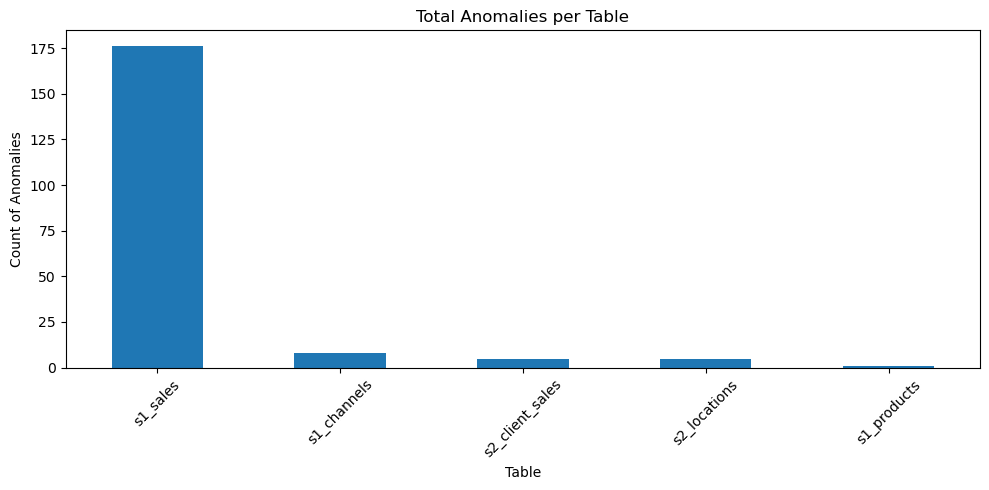

In [44]:
import matplotlib.pyplot as plt
anomalies_per_table = (
    all_issues_df
    .groupby('table_name')
    .size()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 5))

anomalies_per_table.plot(kind='bar')

plt.title('Total Anomalies per Table')
plt.xlabel('Table')
plt.ylabel('Count of Anomalies')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

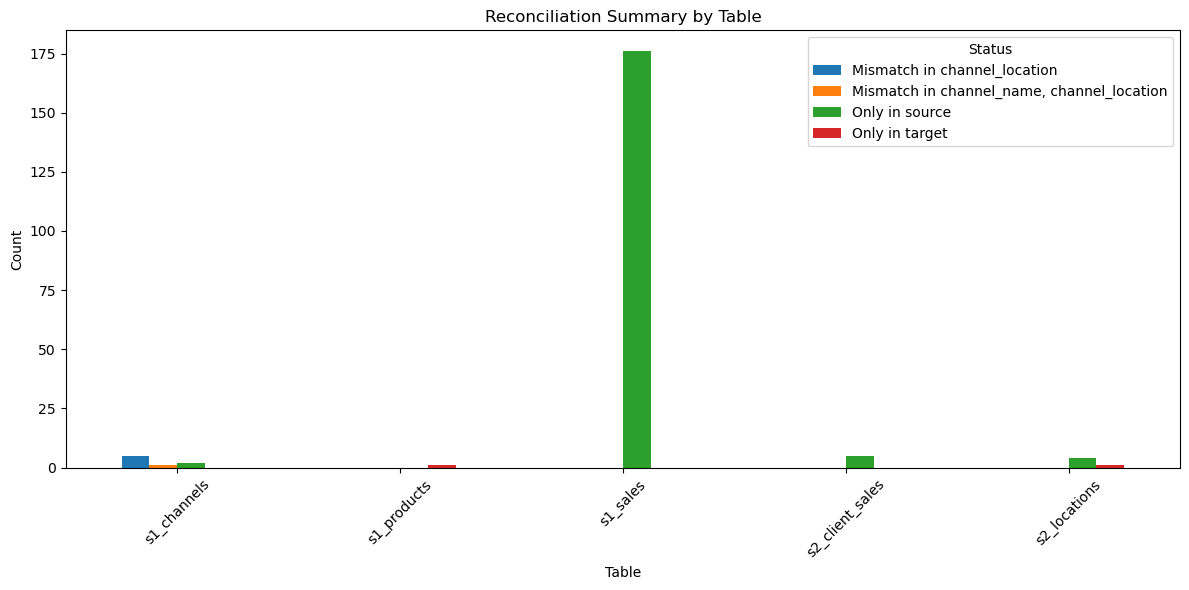

In [45]:
reconciliation_summary = pd.crosstab(
    all_issues_df['table_name'],
    all_issues_df['reconciliation_status']
)

reconciliation_summary.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Reconciliation Summary by Table')
plt.xlabel('Table')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Status')
plt.tight_layout()

plt.show()

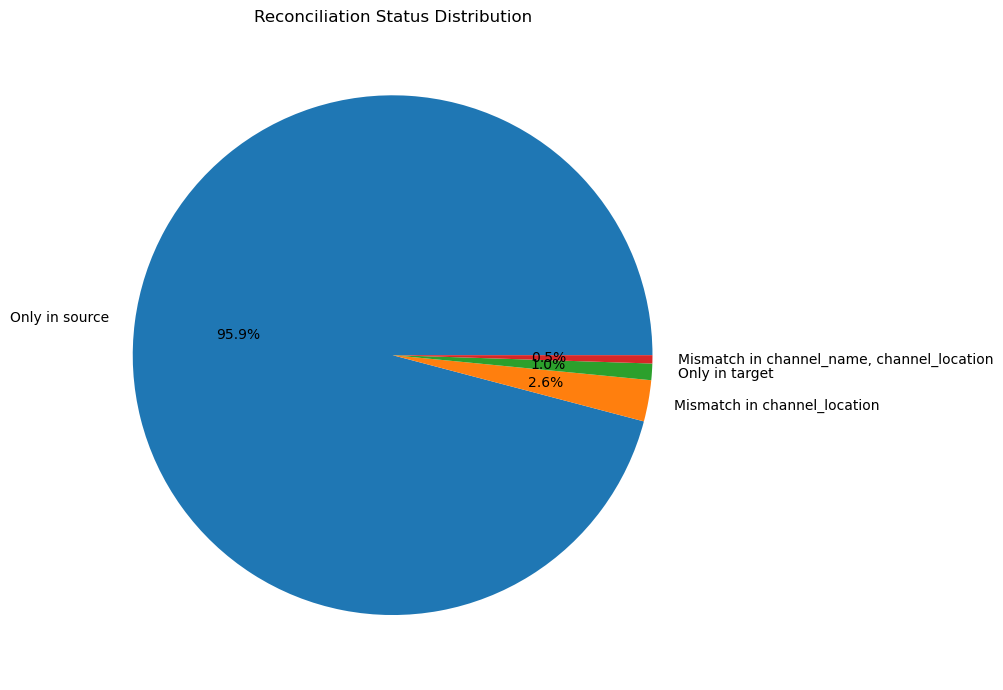

In [46]:
status_distribution = (
    all_issues_df['reconciliation_status']
    .value_counts()
)

plt.figure(figsize=(9, 7))

status_distribution.plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Reconciliation Status Distribution')
plt.ylabel('')
plt.tight_layout()

plt.show()

## Conclusion

The Python reconciliation identified 195 anomalies across the analyzed source and landing tables.

The largest number of discrepancies was found in `s1_sales`, with 176 records present only in the source. Additional issues were detected in `s1_channels`, `s1_products`, `s2_client_sales`, and `s2_locations`, while `s2_channels` and `s2_clients` showed no reconciliation issues.

The reconciliation results demonstrate that the Python-based validation successfully detects missing records and attribute-level differences between the source and landing layers.